In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import files
files.upload()  # a button appears — click it and select kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gospelgabriel","key":"468053d3136c5582e75fe046ccb3eb83"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!pip install -q kaggle
!kaggle datasets download -d aramelheni/crc-gut-microbiome-ml-data
!unzip -o crc-gut-microbiome-ml-data.zip

Dataset URL: https://www.kaggle.com/datasets/aramelheni/crc-gut-microbiome-ml-data
License(s): apache-2.0
100% 1.18M/1.18M [00:00<00:00, 126MB/s]

Archive:  crc-gut-microbiome-ml-data.zip
  inflating: README.md               
  inflating: metadata.csv            
  inflating: seqtab_nochim_export.xlsx  
  inflating: taxa_species_export.xlsx  


In [6]:
!ls

crc-gut-microbiome-ml-data.zip	metadata.csv  seqtab_nochim_export.xlsx
drive				README.md     taxa_species_export.xlsx
kaggle.json			sample_data


In [8]:
import pandas as pd
df = pd.read_csv('metadata.csv')
df.head()

,SampleID;host_disease;SampleName;DiseaseStatus;Sex;Age
0,SRR29923448;CRC1;CT8;Colorectal cancer;male;76
1,SRR29923449;CRC2;CA1;Colorectal cancer;female;71
2,SRR29923450;Healthy1;H5;Healthy;male;58
3,SRR29923451;Polype1;AP20;Adenomatous Polyps;fe...
4,SRR29923452;Healthy2;H8;Healthy;male;63


In [9]:
import pandas as pd

metadata = pd.read_csv('metadata.csv', sep=';')
metadata.head()

,SampleID,host_disease,SampleName,DiseaseStatus,Sex,Age
0,SRR29923448,CRC1,CT8,Colorectal cancer,male,76
1,SRR29923449,CRC2,CA1,Colorectal cancer,female,71
2,SRR29923450,Healthy1,H5,Healthy,male,58
3,SRR29923451,Polype1,AP20,Adenomatous Polyps,female,69
4,SRR29923452,Healthy2,H8,Healthy,male,63


In [10]:
abundance = pd.read_excel('seqtab_nochim_export.xlsx')
print(abundance.shape)
abundance.head()

(59, 6694)


,Unnamed: 0,CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTTTAACTAAGCTATACTAACCCCAGGGTTGGTCAATTTCGTGCCAGCCACCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGATACCCTGGTAGTC,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCGACGCCGCGTGAGCGAAGAAGTATTTCGGTATGTAAAGCTCTATCAGCAGGGAAGAAAATGACGGTACCTGACTAAGAAGCACCGGCTAAATACGTGCCAGCAGCCGCGGTAATACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGATGGGCAAGTCTGATGTGAAAACCCGGGGCTCAACCCCGGGACTGCATTGGAAACTGTTCATCTAGAGTGCTGGAGAGGTAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTACTGGACAGTAACTGACGTTGAGGCTCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCTGGTAGTC,CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTTTAACTAAGCTATACTAACCCCAGGGTTGGTCAATTTCGTGCCAGCCACCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGATACCCGGGTAGTC,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCAACGCCGCGTGAGTGATGACGGCCTTCGGGTTGTAAAGCTCTGTCTTCAGGGACGATAATGACGGTACCTGAGGAGGAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCGAGCGTTGTCCGGATTTACTGGGCGTAAAGGGAGCGTAGGCGGACTTTTAAGTGAGATGTGAAATACCCGGGCTCAACTTGGGTGCTGCATTTCAAACTGGAAGTCTAGAGTGCAGGAGAGGAGAATGGAATTCCTAGTGTAGCGGTGAAATGCGTAGAGATTAGGAAGAACACCAGTGGCGAAGGCGATTCTCTGGACTGTAACTGACGCTGAGGCTCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCTGGTAGTC,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCGACGCCGCGTGAGCGAAGAAGTATTTCGGTATGTAAAGCTCTATCAGCAGGGAAGAAGAAATGACGGTACCTGACTAAGAAGCACCGGCTAAATACGTGCCAGCAGCCGCGGTAATACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGCAGGCGGAAGGCTAAGTCTGATGTGAAAGCCCGGGGCTCAACCCCGGTACTGCATTGGAAACTGGTCATCTAGAGTGTCGGAGGGGTAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTACTGGACGATAACTGACGCTGAGGCTCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCTGGTAGTC,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCGACGCCGCGTGAGCGAAGAAGTATTTCGGTATGTAAAGCTCTATCAGCAGGGAAGAAAATGACGGTACCTGACTAAGAAGCACCGGCTAAATACGTGCCAGCAGCCGCGGTAATACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGATGGGCAAGTCTGATGTGAAAACCCGGGGCTCAACCCCGGGACTGCATTGGAAACTGTTCATCTAGAGTGCTGGAGAGGTAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTACTGGACAGTAACTGACGTTGAGGCTCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCGGGTAGTC,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCGACGCCGCGTGAGCGAAGAAGTATTTCGGTATGTAAAGCTCTATCAGCAGGGAAGAAAATGACGGTACCTGACTAAGAAGCACCGGCTAAATACGTGCCAGCAGCCGCGGTAATACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGATGGGCAAGTCTGATGTGAAAACCCGGGGCTCAACCCCGGGACTGCATTGGAAACTGTTCATCTAGAGTGCTGGAGAGGTAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTACTGGACAGTAACTGACGTTGAGGCTCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCCGGTAGTC,CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTTTAACTAAGCTATACTAACCCCAGGGTTGGTCAATTTCGTGCCAGCCACCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGATACCCTTGTAGTC,CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTTTAACTAAGCTATACTAACCCCAGGGTTGGTCAATTTCGTGCCAGCCACCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGATACCCCGGTAGTC,...,CCTACGGGCGGCAGCAGTGGGGGATATTGCGCAATGGGGGCAACCCTGACGCAGCAACGCCGCGTGAAGGATGAAGGTTTTCGGATTGTAAACTTCTTTTATTAAGGACGAAACTTGACGGTACTTAATGAATAAGCTCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGGAAGGTCCGGGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCCGGAGATTAAGCGTGTTGTGAAATGTAGGTGCTCAACATCTGCACTGCAGCGCGAACTGGTTTCCTTGAGTACGCACAAAGTGGGCGGAATTCGTGGTGTAGCGGTGAAATGCTTAGATATCACGAAGAACTCCGATTGCGAAGGCAGCTCACTGGAGCGCAACTGACGCTGAAGCTCGAAAGTGCGGGTATCGAACAGGATTAGATACCCGGGTAGTC,CCTACGGGAGGCTGCAGTGGGGAATATTGGGCAATGGGCGCAAGCCTGACCCAGCAACGCCGCGTGAAGGAAGAAGGCTTTCGGGTTGTAAACTTCTTTTAACAGGGACGAAGTAAGTGACGGTACCTGTTGAATAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAA

In [11]:
print(metadata['DiseaseStatus'].value_counts())

DiseaseStatus
Colorectal cancer     21
Healthy               19
Adenomatous Polyps    19
Name: count, dtype: int64


In [15]:
import pandas as pd

metadata = pd.read_csv('metadata.csv', sep=';')
abundance = pd.read_excel('seqtab_nochim_export.xlsx')

# Rename the sample-name column in abundance for a clear merge key
abundance = abundance.rename(columns={'Unnamed: 0': 'MergeKey'})

# Merge metadata (labels) with abundance (features)
# We need to merge metadata's 'host_disease' with abundance's 'MergeKey'
merged = pd.merge(metadata, abundance, left_on='host_disease', right_on='MergeKey')

# Drop the redundant MergeKey column if not needed
merged = merged.drop(columns=['MergeKey'])

print(merged.shape)
merged[['SampleName', 'DiseaseStatus']].head()

(59, 6699)


,SampleName,DiseaseStatus
0,CT8,Colorectal cancer
1,CA1,Colorectal cancer
2,H5,Healthy
3,AP20,Adenomatous Polyps
4,H8,Healthy


In [13]:
# Columns that are NOT microbial sequence data
non_feature_cols = ['SampleID', 'host_disease', 'SampleName', 'DiseaseStatus', 'Sex', 'Age']

X = merged.drop(columns=non_feature_cols)
y = merged['DiseaseStatus']

# Drop any sequence columns that are all zero (no signal at all)
X = X.loc[:, (X != 0).any(axis=0)]

print("Features after cleanup:", X.shape)
print(y.value_counts())

Features after cleanup: (0, 0)
Series([], Name: count, dtype: int64)


In [18]:
import pandas as pd

metadata = pd.read_csv('metadata.csv', sep=';')
abundance = pd.read_excel('seqtab_nochim_export.xlsx')

print("Metadata columns:", metadata.columns.tolist())
print("Abundance first column name:", abundance.columns[0])

Metadata columns: ['SampleID', 'host_disease', 'SampleName', 'DiseaseStatus', 'Sex', 'Age']
Abundance first column name: Unnamed: 0


In [19]:
print("metadata['SampleID'] examples:", metadata['SampleID'].head(5).tolist())
print("metadata['host_disease'] examples:", metadata['host_disease'].head(5).tolist())
print("metadata['SampleName'] examples:", metadata['SampleName'].head(5).tolist())
print("\nabundance first-column examples:", abundance.iloc[:5, 0].tolist())

metadata['SampleID'] examples: ['SRR29923448', 'SRR29923449', 'SRR29923450', 'SRR29923451', 'SRR29923452']
metadata['host_disease'] examples: ['CRC1', 'CRC2', 'Healthy1', 'Polype1', 'Healthy2']
metadata['SampleName'] examples: ['CT8', 'CA1', 'H5', 'AP20', 'H8']

abundance first-column examples: ['CRC1', 'CRC10', 'CRC11', 'CRC12', 'CRC13']


In [20]:
abundance_ids = set(abundance.iloc[:, 0])

for col in ['SampleID', 'host_disease', 'SampleName']:
    overlap = len(set(metadata[col]) & abundance_ids)
    print(f"{col}: {overlap} matches out of {len(metadata)} metadata rows")

SampleID: 0 matches out of 59 metadata rows
host_disease: 59 matches out of 59 metadata rows
SampleName: 0 matches out of 59 metadata rows


In [21]:
merged = pd.merge(
    metadata,
    abundance,
    left_on='host_disease',
    right_on=abundance.columns[0]
)

print(merged.shape)
merged[['host_disease', 'DiseaseStatus']].head()

(59, 6700)


,host_disease,DiseaseStatus
0,CRC1,Colorectal cancer
1,CRC2,Colorectal cancer
2,Healthy1,Healthy
3,Polype1,Adenomatous Polyps
4,Healthy2,Healthy


In [22]:
non_feature_cols = ['SampleID', 'host_disease', 'SampleName', 'DiseaseStatus', 'Sex', 'Age', abundance.columns[0]]

X = merged.drop(columns=non_feature_cols)
y = merged['DiseaseStatus']

# Drop sequence columns that are all zero
X = X.loc[:, (X != 0).any(axis=0)]

print("Features after cleanup:", X.shape)
print(y.value_counts())

Features after cleanup: (59, 6693)
DiseaseStatus
Colorectal cancer     21
Healthy               19
Adenomatous Polyps    19
Name: count, dtype: int64


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.5555555555555556
                    precision    recall  f1-score   support

Adenomatous Polyps       0.50      0.67      0.57         6
 Colorectal cancer       0.50      0.67      0.57         6
           Healthy       1.00      0.33      0.50         6

          accuracy                           0.56        18
         macro avg       0.67      0.56      0.55        18
      weighted avg       0.67      0.56      0.55        18



In [24]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Average accuracy:", scores.mean())

Cross-validation scores: [0.91666667 0.83333333 0.83333333 0.58333333 0.45454545]
Average accuracy: 0.7242424242424244


In [25]:
# Focus on the clearest comparison: Healthy vs Colorectal Cancer
binary_mask = merged['DiseaseStatus'].isin(['Healthy', 'Colorectal cancer'])
X_binary = X[binary_mask]
y_binary = merged.loc[binary_mask, 'DiseaseStatus']

print(X_binary.shape)
print(y_binary.value_counts())

(40, 6693)
DiseaseStatus
Colorectal cancer    21
Healthy              19
Name: count, dtype: int64


In [26]:
taxa = pd.read_excel('taxa_species_export.xlsx')
print(taxa.shape)
taxa.head()

(6693, 8)


,Unnamed: 0,Kingdom,Phylum,Class,Order,Family,Genus,Species
0,CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTT...,Bacteria,Proteobacteria,Alphaproteobacteria,Rickettsiales,Mitochondria,NaN,NaN
1,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCC...,Bacteria,Firmicutes,Clostridia,Lachnospirales,Lachnospiraceae,[Ruminococcus] torques group,NaN
2,CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTT...,Bacteria,Proteobacteria,NaN,NaN,NaN,NaN,NaN
3,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCC...,Bacteria,Firmicutes,Clostridia,Clostridiales,Clostridiaceae,Clostridium sensu stricto 1,NaN
4,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCC...,Bacteria,Firmicutes,Clostridia,Lachnospirales,Lachnospiraceae,Roseburia,inulinivorans


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(n_estimators=200, random_state=42)
scores = cross_val_score(model, X_binary, y_binary, cv=5)
print("Binary CV scores:", scores)
print("Average accuracy:", scores.mean())

Binary CV scores: [1.    0.875 1.    0.75  0.75 ]
Average accuracy: 0.875


In [28]:
taxa = pd.read_excel('taxa_species_export.xlsx')
taxa = taxa.rename(columns={'Unnamed: 0': 'sequence'})

# Use the most specific taxonomic level available for each sequence
def get_label(row):
    for level in ['Genus', 'Family', 'Order', 'Class', 'Phylum', 'Kingdom']:
        if pd.notna(row[level]):
            return f"{level}:{row[level]}"
    return "Unknown"

taxa['taxon_label'] = taxa.apply(get_label, axis=1)
seq_to_label = dict(zip(taxa['sequence'], taxa['taxon_label']))

# Rename X_binary's sequence columns to their taxon labels
X_binary_named = X_binary.copy()
X_binary_named.columns = [seq_to_label.get(col, 'Unknown') for col in X_binary_named.columns]

# Sum up abundances for columns that share the same taxon label
X_collapsed = X_binary_named.T.groupby(X_binary_named.columns).sum().T

print("Collapsed shape:", X_collapsed.shape)
X_collapsed.head()

Collapsed shape: (40, 279)


,Class:Actinobacteria,Class:Alphaproteobacteria,Class:Bacilli,Class:Bacteroidia,Class:Clostridia,Class:Cyanobacteriia,Class:Gammaproteobacteria,Family:Anaerovoracaceae,Family:Bifidobacteriaceae,Family:Butyricicoccaceae,...,Order:Peptostreptococcales-Tissierellales,Order:RF39,Order:Rhodospirillales,Order:Rickettsiales,Order:Saccharimonadales,Order:Veillonellales-Selenomonadales,Phylum:Desulfobacterota,Phylum:Firmicutes,Phylum:Proteobacteria,Unknown
0,0,12,0,0,0,0,0,0,0,80,...,0,0,0,19,0,0,0,0,53,9
1,0,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,28,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,29,0,10,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(n_estimators=200, random_state=42)
scores = cross_val_score(model, X_collapsed, y_binary, cv=5)
print("Collapsed CV scores:", scores)
print("Average accuracy:", scores.mean())

Collapsed CV scores: [0.75 0.75 1.   1.   0.75]
Average accuracy: 0.85


In [30]:
model.fit(X_collapsed, y_binary)
importances = pd.Series(model.feature_importances_, index=X_collapsed.columns).sort_values(ascending=False)
print(importances.head(15))

Genus:Christensenellaceae R-7 group    0.044919
Genus:NK4A214 group                    0.044023
Genus:UCG-002                          0.040247
Genus:Anaerostipes                     0.039520
Genus:Lachnospiraceae UCG-010          0.035645
Genus:Lachnospira                      0.030695
Order:Clostridia UCG-014               0.027758
Genus:Monoglobus                       0.025019
Genus:Subdoligranulum                  0.023181
Genus:Fusicatenibacter                 0.021002
Genus:Bifidobacterium                  0.020185
Genus:Blautia                          0.017819
Genus:Peptostreptococcus               0.017100
Genus:UCG-005                          0.016407
Genus:Mogibacterium                    0.016335
dtype: float64


In [31]:
top_features = importances.head(15).index

for feature in top_features:
    means = X_collapsed[feature].groupby(y_binary).mean()
    print(f"{feature}")
    print(means)
    print()

Genus:Christensenellaceae R-7 group
DiseaseStatus
Colorectal cancer    369.476190
Healthy               24.315789
Name: Genus:Christensenellaceae R-7 group, dtype: float64

Genus:NK4A214 group
DiseaseStatus
Colorectal cancer    80.428571
Healthy              18.052632
Name: Genus:NK4A214 group, dtype: float64

Genus:UCG-002
DiseaseStatus
Colorectal cancer    197.380952
Healthy               72.157895
Name: Genus:UCG-002, dtype: float64

Genus:Anaerostipes
DiseaseStatus
Colorectal cancer     26.857143
Healthy              110.842105
Name: Genus:Anaerostipes, dtype: float64

Genus:Lachnospiraceae UCG-010
DiseaseStatus
Colorectal cancer    151.761905
Healthy               18.842105
Name: Genus:Lachnospiraceae UCG-010, dtype: float64

Genus:Lachnospira
DiseaseStatus
Colorectal cancer     31.095238
Healthy              182.210526
Name: Genus:Lachnospira, dtype: float64

Order:Clostridia UCG-014
DiseaseStatus
Colorectal cancer    115.428571
Healthy               14.736842
Name: Order:Clostri

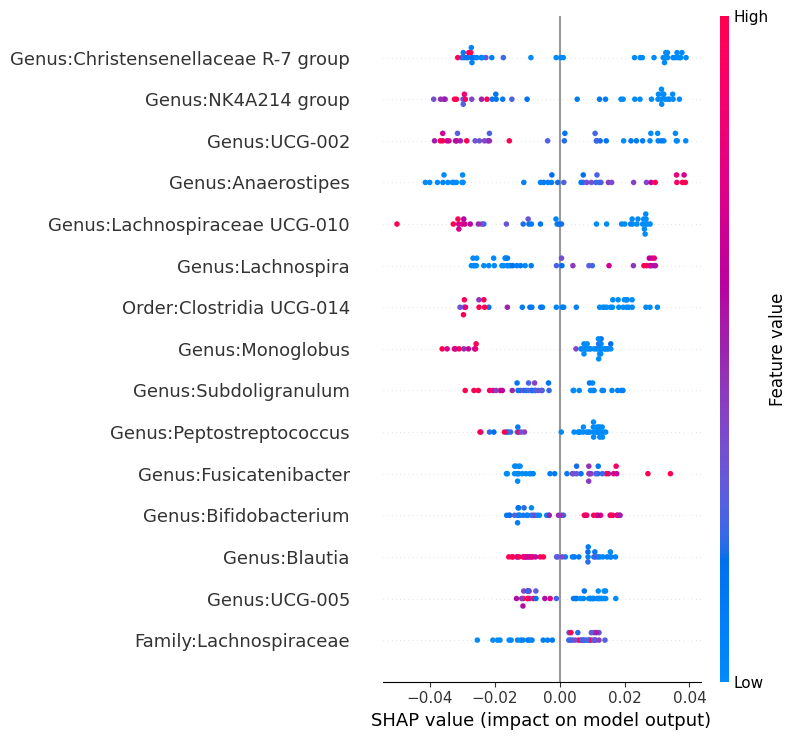

In [32]:
!pip install -q shap
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_collapsed)

# Summary plot: shows which microbes push predictions toward Cancer vs Healthy
shap.summary_plot(shap_values[:, :, 1], X_collapsed, max_display=15)

In [33]:
import matplotlib.pyplot as plt

# Clear any existing plot to ensure a fresh one is generated
plt.clf()

# Create the SHAP summary plot
shap.summary_plot(shap_values[:, :, 1], X_collapsed, max_display=15, show=False) # show=False to prevent immediate display

# Save the plot to a file
plot_filename = 'shap_summary_plot.png'
plt.savefig(plot_filename, bbox_inches='tight')
print(f"SHAP plot saved as '{plot_filename}'")

# Close the plot to free up memory
plt.close()

SHAP plot saved as 'shap_summary_plot.png'


In [34]:
import os

drive_folder_name = 'colab_output'
drive_folder_path = os.path.join('/content/drive/MyDrive', drive_folder_name)

# Create the folder if it doesn't exist
os.makedirs(drive_folder_path, exist_ok=True)
print(f"Google Drive folder '{drive_folder_name}' created or already exists at '{drive_folder_path}'")

Google Drive folder 'colab_output' created or already exists at '/content/drive/MyDrive/colab_output'


In [35]:
import shutil

# Define source and destination paths
source_path = plot_filename
destination_path = os.path.join(drive_folder_path, plot_filename)

# Move the file
shutil.move(source_path, destination_path)
print(f"Moved '{plot_filename}' to '{destination_path}'")


Moved 'shap_summary_plot.png' to '/content/drive/MyDrive/colab_output/shap_summary_plot.png'
